## High-Dimensional Data, Dimensionality Reduction & PCA  

### High-Dimensional Data
A dataset is said to be **high-dimensional** when it contains a very large number of features (columns/variables) compared to the number of observations (rows).  

#### Examples
- Low-dimensional data: 3 features such as Height, Weight, and Age.  
- High-dimensional data: 10,000 features such as gene expression levels for patients, image pixel values, or text embeddings.  

### What are High-Dimensional Spaces?

A `high-dimensional space` is simply the mathematical space where the data lives when it has many features (dimensions/variables).

- Each feature in the dataset represents a dimension (axis).
- A dataset with 2 features lives in a 2D space (you can plot it on a flat plane).
- A dataset with 3 features lives in a 3D space (you can visualize it as a cube).
- A dataset with 100 features lives in a 100-dimensional space (you cannot visualize this directly, but mathematically it exists).

### Problems of High-Dimensional Data (Curse of Dimensionality)

The Curse of Dimensionality is a critical challenge in machine learning, particularly as datasets grow in complexity with more features. 

In high-dimensional spaces, algorithms struggle to maintain accuracy, and data points become sparse, making it harder to identify meaningful patterns. 
1. **Sparsity of data**  
   - Data becomes more sparse as the number of dimensions increases. 
   - The dotted lines in the three-dimensional representation are to clarify the position of the points along the z-axis. 
   - Note the increasing empty space with increased dimensions.

   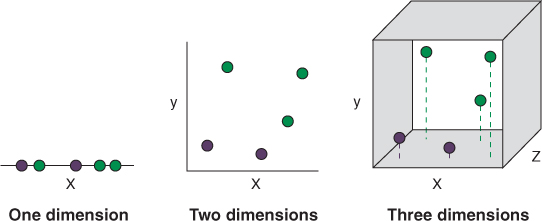

2. **Breakdown of distance measures**  
   - Algorithms such as k-Nearest Neighbors or clustering rely on distances between points.  
   - In high dimensions, distances between all points tend to become similar, reducing their usefulness.  

3. **Overfitting in models**  
   - As the number of features (dimensions) increases, the volume of the space grows exponentially, causing data points to become sparse.
   - This sparsity makes it difficult for machine learning algorithms to detect patterns effectively, leading to issues like overfitting.   
   - This reduces predictive performance on new data.  

4. **High computational cost**  
   - More features require more storage, more processing power, and longer training times.  

5. **Difficulty in visualization**  
   - Humans can only visualize data in two or three dimensions.  
   - Plotting data with more than three features requires dimensionality reduction.  

## Curse of Dimensionality in Machine Learning: How Can You Solve It?
### Dimensionality Reduction
`Dimensionality reduction` is the process of reducing the number of input variables in a dataset while retaining as much useful information as possible.  

### Why Dimensionality Reduction is Important
- Removes irrelevant or redundant features.  
- Helps to prevent overfitting by simplifying models.  
- Reduces computational requirements, making algorithms run faster.  
- Makes it possible to visualize high-dimensional data in 2D or 3D.  
- Improves the performance of distance-based algorithms by removing noise.  

## Approaches to Dimensionality Reduction

### A. Feature Selection
Feature selection reduces dimensionality by **choosing a subset of the original features**. It does not create new features.  

Methods:
- **Filter methods**: Select features based on statistical tests such as correlation, chi-square test, or ANOVA.  
- **Wrapper methods**: Use predictive models to evaluate subsets of features, e.g., forward selection, backward elimination, or recursive feature elimination (RFE).  
- **Embedded methods**: Select features as part of model training, e.g., LASSO regression, Decision Trees, or Random Forest feature importance.  

### B. Feature Extraction
Feature extraction reduces dimensionality by **transforming the original features into a new set of features**. These new features are usually fewer in number and more informative.  

Methods:
- **Principal Component Analysis (PCA)**: A linear method that finds new axes (principal components) which capture maximum variance in the data.  
- **Linear Discriminant Analysis (LDA)**: A supervised method that finds axes that maximize the separation between classes.  
- **t-SNE (t-Distributed Stochastic Neighbor Embedding)**: A nonlinear method for visualizing high-dimensional data in 2D or 3D.  
- **UMAP (Uniform Manifold Approximation and Projection)**: A nonlinear method that preserves both local and global structure in the data.  
- **Autoencoders**: Neural networks that learn to compress data into a lower-dimensional representation and reconstruct it back.  

## Principal Component Analysis (PCA)

### What is PCA?
PCA is a **dimensionality reduction technique** that takes many original features and transforms them into a smaller number of new features called **principal components**.  

The goal is to retain as much useful `variation` in the data as possible while reducing the number of dimensions.

Imagine we have a dataset containing information about customers applying for loans:

- Annual income (KES)
- Loan amount (KES)
- Monthly repayment (KES)

Notice that these features may be related. Customers with higher incomes may qualify for larger loans and have larger repayments.

This means some of the features contain overlapping information.

PCA attempts to combine such information into fewer dimensions.

PCA tries to find this direction of greatest variation.

### Understand what variance means

`Variance` measures how much values differ from their average.

For example, if all customers have almost the same income, income has low variance. If incomes vary widely, income has high variance.

In PCA, variance is important because it helps identify the directions in which the data varies the most.

### What are Principal Components?
- These components are **linear combinations of the original features**.  
- The components are constructed such that:  
  - **PC1** captures the maximum variance (the largest spread of the data).  
  - **PC2** captures the next largest variance, orthogonal (perpendicular) to PC1.  
  - **PC3, PC4, …** continue in the same way.  
- PCA is **unsupervised** because it does not use class labels. 
- A **principal component** is **not one of the original features**.  
- It is a **new variable**, formed as a **weighted sum of the original features**.  

Example (not actual Iris values):
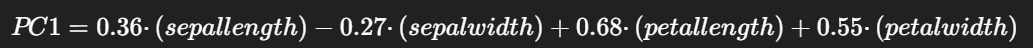

- The numbers `(0.36, -0.27, 0.68, 0.55)` are called loadings (eigenvector coefficients).
- They tell us how much each feature contributes to the component.

## Steps of the PCA Algorithm

The main idea for PCA is:

> **Find the directions where the data varies the most, then keep the most important directions.**

### 1. Standardize the Data

First, we put all the features on a **similar scale**.

We do this because PCA is affected by the size of the numbers in our features.

For example:

* Age: 18–60
* Salary: 30,000–500,000
* Number of children: 0–5

Salary has much larger numbers than the other features. Without standardization, it could have a much bigger influence on PCA.

We commonly standardize using:

$$
z = \frac{x-\mu}{\sigma}
$$

After standardization:

* Mean = 0
* Standard deviation = 1
* Variance = 1

### In simple terms:

> **Put all features on a fair playing field.**

### 2. Compute the Covariance Matrix

Next, PCA looks at **how the features vary together**.

This is done using a **covariance matrix**.

For example, suppose we have:

* Age
* Salary
* Years of experience

The covariance matrix helps us understand relationships such as:

> Do people with more years of experience tend to have higher salaries?

### Covariance tells us:

* **Positive covariance:** Two features tend to increase together.
* **Negative covariance:** One tends to increase while the other decreases.
* **Close to zero:** There is little linear relationship.

### In simple terms:

> **The covariance matrix helps PCA understand how the features are related to each other.**

### 3. Find Eigenvectors and Eigenvalues

This is where PCA finds the **new directions** for our data.

#### Eigenvectors = Directions

Eigenvectors tell us the **directions in which the data varies**.

These directions become our **principal components**.

Think of a dataset as a cloud of points.

PCA looks for a direction through that cloud where the points are spread out the most.

That direction becomes **PC1**.

It then finds another important direction, which becomes **PC2**, and so on.

### Eigenvalues = Amount of Variance

Eigenvalues tell us **how much variance each direction captures**.

For example:

| Component | Eigenvalue |
| --------- | ---------: |
| PC1       |        5.0 |
| PC2       |        2.0 |
| PC3       |        0.5 |

PC1 has the largest eigenvalue, so it captures the most variance.

### Easy way to remember:

> **Eigenvectors tell us the direction.**
> **Eigenvalues tell us how important that direction is.**

### 4. Rank the Principal Components

We arrange the principal components from the one that captures the most variance to the one that captures the least.

For example:

```text
PC1 → 60% variance
PC2 → 25% variance
PC3 → 10% variance
PC4 → 5% variance
```

So:

```text
PC1 > PC2 > PC3 > PC4
```

PC1 is the most important because it captures the most variance.

### In simple terms:

> **Put the principal components in order from most informative to least informative.**

### 5. Choose the Components to Keep

Now we decide how many components we want to keep.

We can use **explained variance** to help us make this decision.

For example:

| Component | Variance Explained | Cumulative Variance |
| --------- | -----------------: | ------------------: |
| PC1       |                60% |                 60% |
| PC2       |                25% |                 85% |
| PC3       |                10% |                 95% |
| PC4       |                 5% |                100% |

If we want to keep **95% of the information**, we keep:

```text
PC1
PC2
PC3
```

We can then reduce our dataset to these 3 components.

### In simple terms:

> **Keep enough components to preserve the amount of information we need.**

A common target is **90% or 95% explained variance**.

### 6. Transform the Data

Finally, we transform our original data using the principal components we selected.

For example, suppose our original dataset had:

```text
10 Features
```

After PCA, we might keep:

```text
3 Principal Components
```

So:

```text
Original Data
10 Features
     ↓
    PCA
     ↓
Reduced Data
3 Principal Components
```

The new features are:

```text
PC1
PC2
PC3
```

These are **not simply three of the original features**.

They are new features created by combining information from the original features.

### In simple terms:

> **Convert the original data into a smaller number of principal components.**

### What is PCA Trying to Do?

Imagine you have a dataset with many features:

```text
Feature 1
Feature 2
Feature 3
Feature 4
Feature 5
Feature 6
Feature 7
Feature 8
```

Some of these features may contain **similar or overlapping information**.

PCA tries to find a smaller number of new features that capture most of the variation:

```text
8 Original Features
        ↓
       PCA
        ↓
PC1 + PC2 + PC3
```

So instead of working with 8 features, we might work with only 3 while retaining most of the important variation in the data.

> **PCA = Find the most important directions of variation and use them to represent the data with fewer dimensions.**
 

### Example of PCA
- Original dataset has 100 features.  
- PCA analysis shows that 10 principal components explain 95% of the variance.  
- Instead of using all 100 features, the dataset can be reduced to 10 principal components, making it simpler and less prone to overfitting.  


### When should you consider PCA?

- When there are too many features: For example, a dataset has 800 numerical features, making the model complex and computationally expensive.

- When features are highly correlated: Several features may carry similar information. PCA combines them into fewer components.

- When overfitting is a concern: Reducing dimensions may help a model generalize better, although this is not guaranteed.

- When visualization is needed: PCA can reduce data to 2 or 3 dimensions to visualize patterns or clusters.

- When the model benefits from fewer features: Some algorithms, such as logistic regression or SVM, may benefit from a lower-dimensional representation.

### When might PCA not be the best choice?

- When the dataset has only a few relevant features.

- When interpretability is critical, such as explaining why a customer was denied a loan.

- When most features are categorical and have not been appropriately encoded.

- When feature selection can achieve the desired reduction while preserving meaningful business information.

### Real-World Example:

#### Facial Recognition (Eigenfaces)

- You have thousands of face images (e.g., security systems, photo tagging on social media).
- Each image might be 100×100=10,000 pixels → 10,000 features per face.
- That’s too high-dimensional and inefficient for storage + computation.

### How PCA Helps

#### 1. Flatten the Images
- Each image is reshaped into a **10,000-dimensional vector**.  

#### 2. Apply PCA
- PCA finds the **principal components** (the directions that explain the most variance in faces).  
- Instead of storing all 10,000 pixels, we might only need the top **100 components**.  

#### 3. Reconstruct Faces
- With those 100 components (called **eigenfaces**), we can still reconstruct faces with high accuracy.  

#### 4. Recognition Task
- New face → project into PCA space → compare with stored projections.  
- This makes facial recognition **faster and more robust**. 

- PCA “learns” the main features that vary across faces:
    - Eye position
    - Nose shape
    - Mouth width
    - Head orientation
- So instead of memorizing every pixel, PCA compresses the dataset into a smaller set of meaningful features.

### Python Code to Mitigate the Curse of Dimensionality:

####  Import Necessary Libraries

In [45]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

#### Load the Dataset

In [46]:
# Load the Iris dataset
data = load_iris()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

In [47]:
# Display the first few rows
print("First 5 rows of the dataset:")
print(X.head())

First 5 rows of the dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [4]:
X.shape

(150, 4)

In [5]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


#### Split the Data and Standardize

Split the data into training and testing sets and standardize the features to ensure all variables contribute equally to the analysis.

In [6]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Fit PCA (full) on training data and inspect explained variance

In [17]:
# fit PCA with all components (so we can inspect explained variance)
pca_full = PCA()                        # n_components=None -> all components
pca_full.fit(X_train_scaled)

explained_var = pca_full.explained_variance_ratio_
print("Explained variance ratio (per PC):", np.round(explained_var, 4))
print("Cumulative explained variance:", np.round(np.cumsum(explained_var), 4))


Explained variance ratio (per PC): [0.7255 0.23   0.0396 0.0049]
Cumulative explained variance: [0.7255 0.9555 0.9951 1.    ]


- `Explained variance` ratio per PC = proportion of the dataset’s information (variance) captured by each principal component.
- `Cumulative explained` variance = running total, showing how much variance is captured if we keep the first k components.

- PC1 (72.55%)
    - Captures most of the variance in the dataset.
    - This means a single axis (linear combination of features) already describes ~73% of the differences among Iris flowers.

- PC2 (23.00%)
    - Adds another ~23% of variance.
    - Together, PC1 + PC2 explain 95.55% of the variance, that’s why 2D PCA works so well for Iris visualization.

- PC3 (3.96%)
    - Adds very little, almost negligible new information.

- PC4 (0.49%)
    - Captures almost nothing (essentially noise).

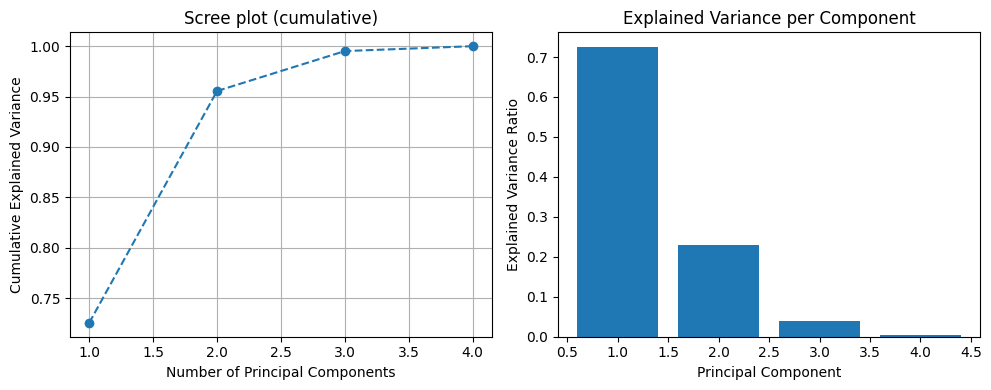

In [ ]:
# scree & bar plot
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(np.arange(1, len(explained_var)+1), np.cumsum(explained_var),
         marker='o', linestyle='--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree plot (cumulative)')
plt.grid(True)

plt.subplot(1,2,2)
plt.bar(np.arange(1, len(explained_var)+1), explained_var)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance per Component')

plt.tight_layout()
plt.show()


In [ ]:
#choose number of components to retain 95% variance
threshold = 0.95
cumvar = np.cumsum(explained_var)
n_needed = np.argmax(cumvar >= threshold) + 1
print(f"Number of components to retain >= {threshold*100:.0f}% variance: {n_needed}")


Number of components to retain >= 95% variance: 2


In [ ]:
# fit PCA with chosen number of components 
n_components = n_needed  
pca = PCA(n_components=n_components)
X_train_pca = pca.fit_transform(X_train_scaled)  # fit on train
X_test_pca  = pca.transform(X_test_scaled)       # transform test


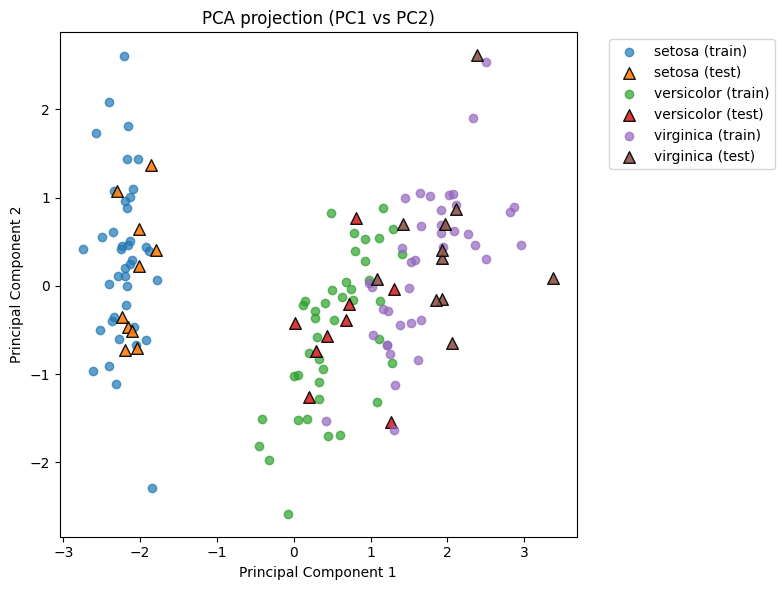

In [ ]:
# 2D scatter of first two principal components
if n_components >= 2:
    plt.figure(figsize=(8,6))
    for cls, name in enumerate(data.target_names):
        # train points for this class
        idx_train = (y_train == cls).to_numpy()
        plt.scatter(X_train_pca[idx_train, 0], X_train_pca[idx_train, 1],
                    marker='o', alpha=0.7, label=f"{name} (train)")

        # test points for this class
        idx_test = (y_test == cls).to_numpy()
        plt.scatter(X_test_pca[idx_test, 0], X_test_pca[idx_test, 1],
                    marker='^', edgecolors='k', s=70, alpha=0.9, label=f"{name} (test)")

    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.title('PCA projection (PC1 vs PC2)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # put legend to the right
    plt.tight_layout()
    plt.show()
else:
    print("n_components < 2 — no 2D scatter to show.")


In [ ]:
# pipeline example (scaling + PCA + classifier) - fit only on training data
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

pipe = make_pipeline(StandardScaler(), PCA(n_components=2), LogisticRegression(random_state=42))
pipe.fit(X_train, y_train)                  # pipeline fits scaler+PCA on train internally
y_pred = pipe.predict(X_test)
print("Test accuracy (pipeline w/ PCA(2)):", accuracy_score(y_test, y_pred))


Test accuracy (pipeline w/ PCA(2)): 0.9


## Facial Recognition using PCA and K-Nearest Neighbors

### Importing Libraries

In [7]:
# Core scientific libraries
import numpy as np
import matplotlib.pyplot as plt

# Data handling
from sklearn.datasets import fetch_lfw_people 

# Preprocessing & dimensionality reduction
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler  # if not using whiten=True

# Model
from sklearn.neighbors import KNeighborsClassifier

# Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Visualization 
import seaborn as sns   # for heatmaps and enhanced plots
import matplotlib.pyplot as plt

### Load dataset

In [8]:
# Load the LFW dataset with faces having at least 60 images
faces = fetch_lfw_people(min_faces_per_person=60, resize=0.4)
X, y = faces.data, faces.target
images = faces.images
target_names = faces.target_names

### Understanding the data

In [9]:
# Display shape information
dataset_info = {
    "X_shape": X.shape,
    "image_shape": images[0].shape,
    "num_classes": len(target_names)
}
dataset_info

{'X_shape': (1348, 1850), 'image_shape': (50, 37), 'num_classes': 8}

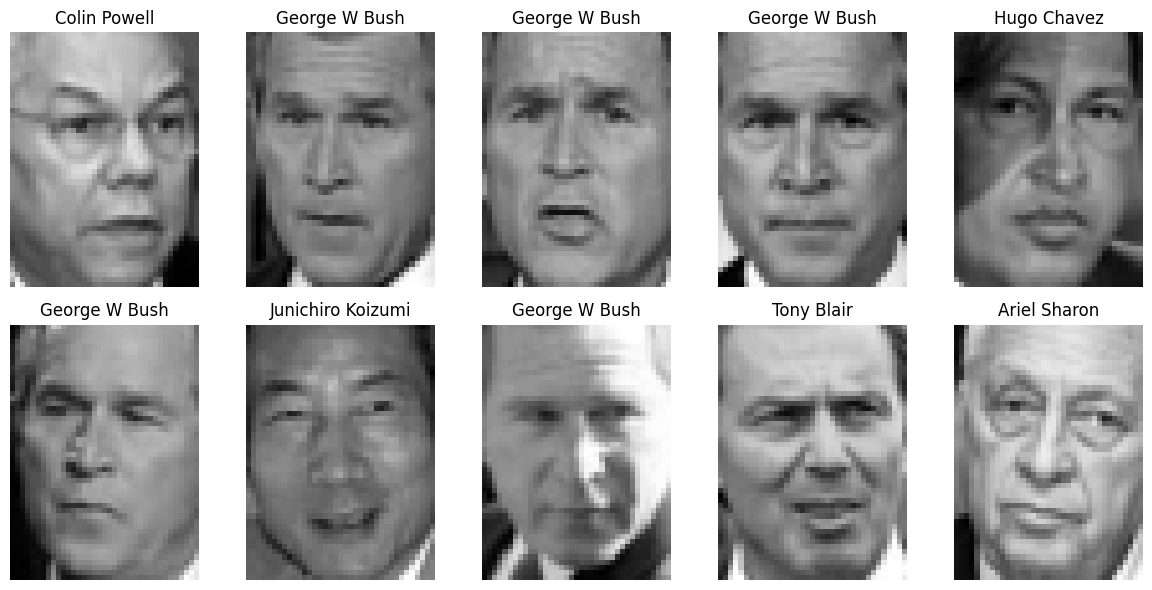

In [10]:
# Show the first few faces
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i], cmap="gray")
    ax.set_title(target_names[y[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()

#### People being recognized

In [12]:
print("People being recognized:")
for i, name in enumerate(target_names):
    print(f"{i}: {name}")

People being recognized:
0: Ariel Sharon
1: Colin Powell
2: Donald Rumsfeld
3: George W Bush
4: Gerhard Schroeder
5: Hugo Chavez
6: Junichiro Koizumi
7: Tony Blair


### Images per class

In [20]:
# Count the number of images for each person
class_counts = pd.Series(y).value_counts().sort_index()

# Display the distribution
for class_id, count in class_counts.items():
    print(f"{target_names[class_id]}: {count} images")

Ariel Sharon: 77 images
Colin Powell: 236 images
Donald Rumsfeld: 121 images
George W Bush: 530 images
Gerhard Schroeder: 109 images
Hugo Chavez: 71 images
Junichiro Koizumi: 60 images
Tony Blair: 144 images


#### Sample faces of the people being recognized

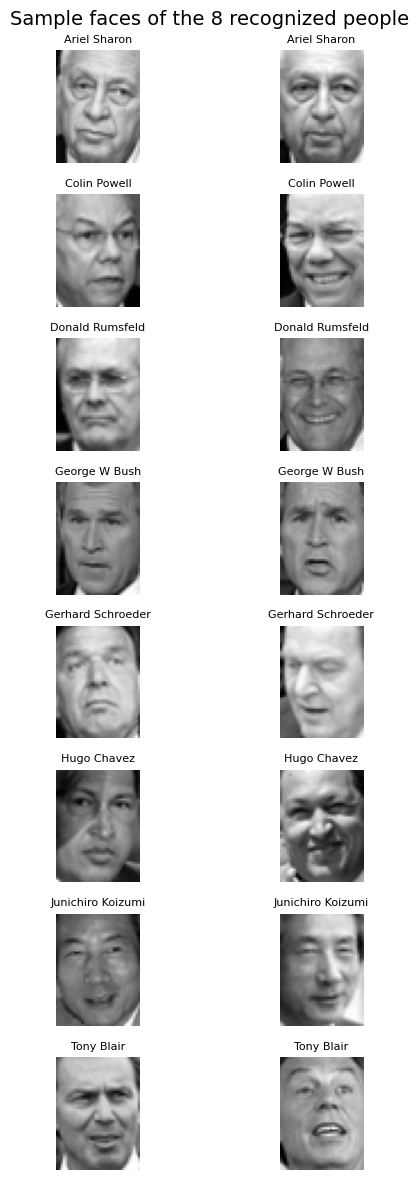

In [21]:
# Plot first 2 faces for each person
fig, axes = plt.subplots(len(target_names), 2, figsize=(6, 12))

for person_id, person_name in enumerate(target_names):
    # Find indices of images belonging to this person
    person_idx = np.where(y == person_id)[0][:2]  # take first 2
    for j, idx in enumerate(person_idx):
        ax = axes[person_id, j]
        ax.imshow(images[idx], cmap="gray")
        ax.set_title(person_name, fontsize=8)
        ax.axis("off")

plt.suptitle("Sample faces of the 8 recognized people", fontsize=14)
plt.tight_layout()
plt.show()


### Apply PCA to Face Dataset
We reduce dimensionality to 100 principal components using randomized SVD and whitening.

In [22]:
from sklearn.decomposition import PCA

# Step 1: Initialize PCA (keep 100 components for example)
pca = PCA(n_components=100, svd_solver='randomized', whiten=True)

# Step 2: Fit PCA on the face dataset
X_pca = pca.fit_transform(X)

print("Original shape:", X.shape)
print("Transformed shape:", X_pca.shape)

Original shape: (1348, 1850)
Transformed shape: (1348, 100)


`whiten=True:` scales the components so they have unit variance. This helps some models (like KNN) perform better, because all components contribute equally.

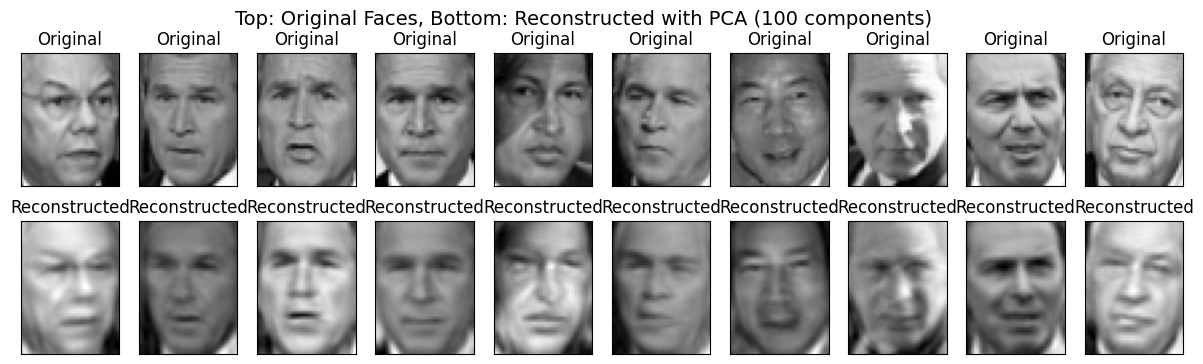

In [23]:
# Step 3: Reconstruct some faces from PCA components
X_reconstructed = pca.inverse_transform(X_pca)

# Show a comparison of original vs reconstructed faces
fig, axes = plt.subplots(2, 10, figsize=(15, 4),
                         subplot_kw={'xticks':[], 'yticks':[]})

for i in range(10):
    # Original
    axes[0, i].imshow(images[i], cmap="gray")
    axes[0, i].set_title("Original")

    # Reconstructed
    axes[1, i].imshow(X_reconstructed[i].reshape(images[0].shape), cmap="gray")
    axes[1, i].set_title("Reconstructed")

plt.suptitle("Top: Original Faces, Bottom: Reconstructed with PCA (100 components)", fontsize=14)
plt.show()

#### inspect PCA: explained variance + top eigenfaces

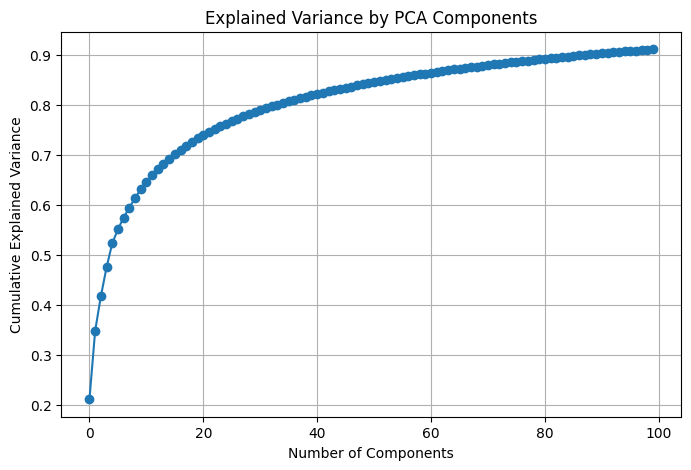

In [24]:
# Explained variance ratio (how much info each PC keeps)
explained_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(explained_variance, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by PCA Components")
plt.grid(True)
plt.show()

#### Visualize Eigenfaces

Each principal component can be reshaped back into the image size → these are called eigenfaces.

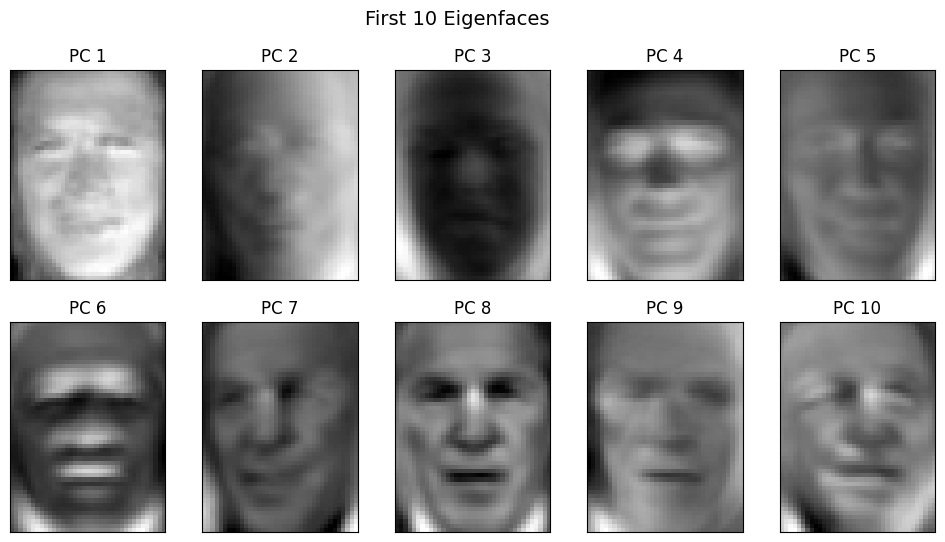

In [17]:
fig, axes = plt.subplots(2, 5, figsize=(12, 6),
                         subplot_kw={'xticks':[], 'yticks':[]})

for i, ax in enumerate(axes.flat):
    ax.imshow(pca.components_[i].reshape(images[0].shape), cmap="gray")
    ax.set_title(f"PC {i+1}")

plt.suptitle("First 10 Eigenfaces", fontsize=14)
plt.show()

### Modelling using KNN

In [25]:
# Baseline KNN in PCA space (proper: PCA fitted on train only)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [26]:
# 1) Train/test split (stratified)
X_train, X_test, y_train, y_test, imgs_train, imgs_test = train_test_split(
    X, y, images, test_size=0.20, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (1078, 1850) Test shape: (270, 1850)


In [27]:
# 2) Fit PCA on training set only
n_components = 100
pca_train = PCA(n_components=n_components, svd_solver='randomized', whiten=True, random_state=42)
X_train_pca = pca_train.fit_transform(X_train)
X_test_pca = pca_train.transform(X_test)

print("PCA fitted on train. Shapes ->", X_train_pca.shape, X_test_pca.shape)

PCA fitted on train. Shapes -> (1078, 100) (270, 100)


In [28]:
# 3) Train baseline KNN (k=5)
knn = KNeighborsClassifier(n_neighbors=5, weights='uniform')
knn.fit(X_train_pca, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [29]:
# 4) Predict & evaluate
y_pred = knn.predict(X_test_pca)
acc = accuracy_score(y_test, y_pred)
print(f"Baseline KNN accuracy (k=5) in PCA space: {acc:.4f}\n")
print("Classification report:\n")
print(classification_report(y_test, y_pred, target_names=target_names))

Baseline KNN accuracy (k=5) in PCA space: 0.6630

Classification report:

                   precision    recall  f1-score   support

     Ariel Sharon       0.43      0.38      0.40        16
     Colin Powell       0.73      0.77      0.75        47
  Donald Rumsfeld       0.54      0.29      0.38        24
    George W Bush       0.64      0.93      0.76       106
Gerhard Schroeder       0.71      0.23      0.34        22
      Hugo Chavez       0.88      0.50      0.64        14
Junichiro Koizumi       0.88      0.58      0.70        12
       Tony Blair       0.71      0.41      0.52        29

         accuracy                           0.66       270
        macro avg       0.69      0.51      0.56       270
     weighted avg       0.67      0.66      0.64       270



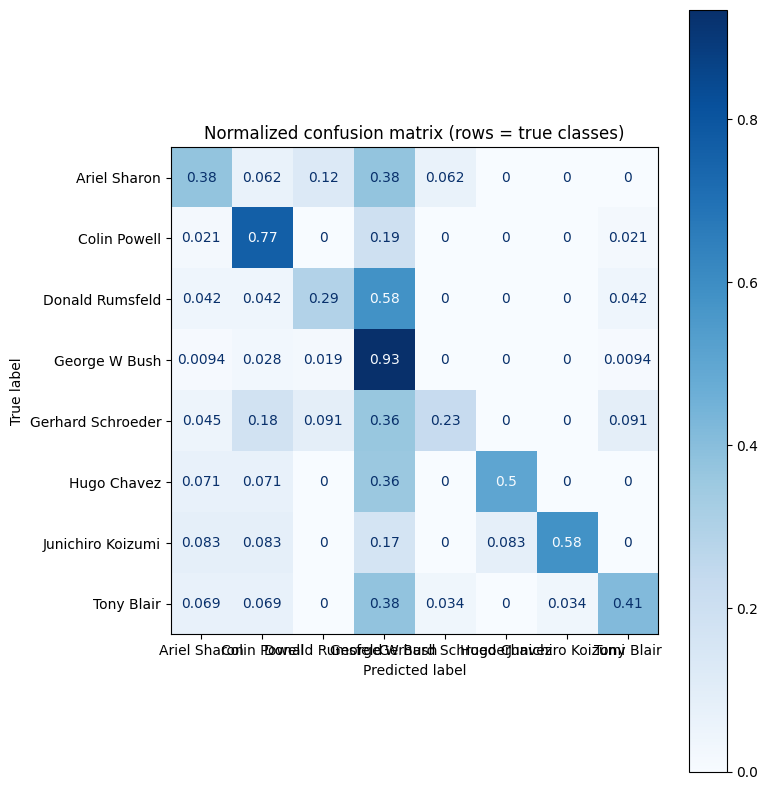

In [30]:
# 5) Confusion matrix (normalized by true class)
cm = confusion_matrix(y_test, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
fig, ax = plt.subplots(figsize=(8,8))
disp.plot(ax=ax, cmap='Blues', colorbar=True)
plt.title("Normalized confusion matrix (rows = true classes)")
plt.tight_layout()
plt.show()

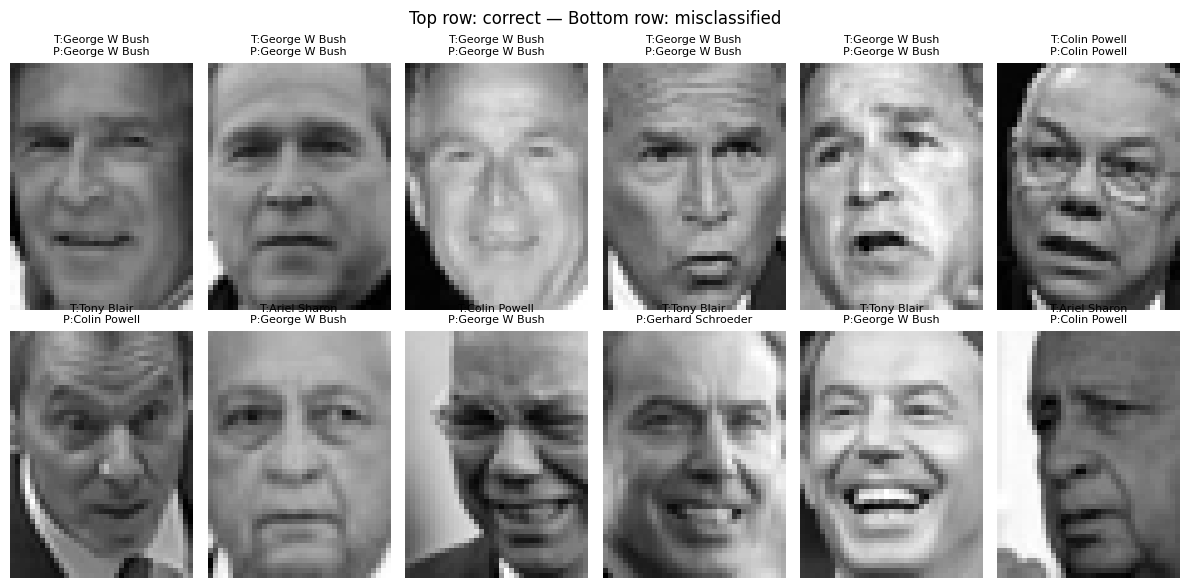

In [31]:
# 6) Show some correct vs misclassified examples
correct_idxs = np.where(y_pred == y_test)[0]
wrong_idxs   = np.where(y_pred != y_test)[0]

n_show = min(6, len(correct_idxs), len(wrong_idxs))
plt.figure(figsize=(12, 6))
for i in range(n_show):
    idx = correct_idxs[i]
    ax = plt.subplot(2, n_show, i+1)
    ax.imshow(imgs_test[idx], cmap='gray'); ax.axis('off')
    ax.set_title(f"T:{target_names[y_test[idx]]}\nP:{target_names[y_pred[idx]]}", fontsize=8)

for i in range(n_show):
    idx = wrong_idxs[i]
    ax = plt.subplot(2, n_show, n_show + i + 1)
    ax.imshow(imgs_test[idx], cmap='gray'); ax.axis('off')
    ax.set_title(f"T:{target_names[y_test[idx]]}\nP:{target_names[y_pred[idx]]}", fontsize=8)

plt.suptitle("Top row: correct — Bottom row: misclassified")
plt.tight_layout()
plt.show()

### Incremental PCA

Incremental principal component analysis (IPCA) is typically used as a replacement for principal component analysis (PCA) when the dataset to be decomposed is too large to fit in memory. 

Instead of computing `PCA` on the entire dataset at once, `IPCA` processes the data in mini-batches (chunks) and incrementally updates the principal components.

### Why use Incremental PCA?

- Standard PCA requires loading the full dataset into memory to compute the covariance matrix and perform SVD.
- For very large datasets (e.g., millions of samples, high-dimensional images), this becomes impossible.
- IPCA avoids memory issues by:
    - Splitting data into smaller chunks.
    - Updating the decomposition incrementally.

### Examples of Incremental PCA (IPCA)

#### Face Recognition on Large Image Datasets
- Datasets like **LFW (Labeled Faces in the Wild)** or company security camera logs can have **millions of face images**.  
- Each image (say 100×100 pixels) = 10,000 features. With millions of images, that’s **terabytes of data**.  
- **Challenge:** Regular PCA can’t load all images into memory at once.  
- **Solution:** Use **Incremental PCA**:  
  - Load a few thousand images at a time.  
  - Update the PCA components batch by batch.  
  - Reduce image dimensions before applying classification (e.g., SVM, KNN) for face recognition.  

#### Credit Card Fraud Detection
- Banks process **billions of transactions daily**.  
- Each transaction has many features (amount, time, location, merchant type, device ID, etc.).  
- **Challenge:** Data is too big for in-memory PCA.  
- **Solution:** IPCA reduces dimensionality batch by batch, making the data manageable for anomaly detection algorithms.  

#### Medical Imaging (MRI/CT Scans)
- Hospitals store massive amounts of **MRI or CT scan images** (each scan can be 3D and high-resolution).  
- Researchers use PCA for compression/feature extraction.  
- **Challenge:** Too many images to load at once.  
- **Solution:** IPCA processes scans incrementally, extracting key features for diagnosis or research.  


### IPCA Example

#### Importing Libraries

In [32]:
from sklearn.decomposition import IncrementalPCA
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

# Train/test split
from sklearn.model_selection import train_test_split

In [33]:
# Load dataset
digits = load_digits()
X = digits.data      
y = digits.target

#### Dataset shape and structure

In [34]:
print("X shape:", X.shape)   # features
print("y shape:", y.shape)   # labels
print("Image shape:", digits.images[0].shape)

X shape: (1797, 64)
y shape: (1797,)
Image shape: (8, 8)


In [35]:
print("Labels:", y[:20])

Labels: [0 1 2 3 4 5 6 7 8 9 0 1 2 3 4 5 6 7 8 9]


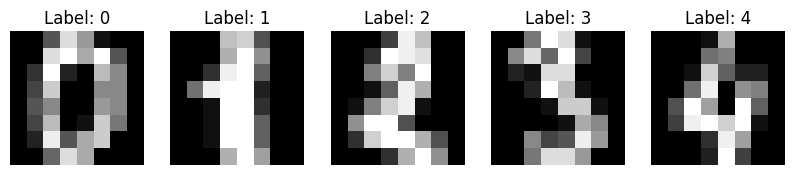

In [36]:
fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for i, ax in enumerate(axes):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f"Label: {y[i]}")
    ax.axis("off")
plt.show()

#### Distribution of digits (class balance)

In [37]:
unique, counts = np.unique(y, return_counts=True)
digit_distribution = dict(zip(unique, counts))
print(digit_distribution)

{np.int64(0): np.int64(178), np.int64(1): np.int64(182), np.int64(2): np.int64(177), np.int64(3): np.int64(183), np.int64(4): np.int64(181), np.int64(5): np.int64(182), np.int64(6): np.int64(181), np.int64(7): np.int64(179), np.int64(8): np.int64(174), np.int64(9): np.int64(180)}


#### Standardize the data

In [38]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#### Apply Incremental PCA (IPCA)

In [39]:
# Initialize IPCA
ipca = IncrementalPCA(n_components=20, batch_size=200)

# Fit and transform
X_ipca = ipca.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("Reduced shape:", X_ipca.shape)

Original shape: (1797, 64)
Reduced shape: (1797, 20)


- `batch_size=200` - IPCA will process the data in mini-batches of 200 samples at a time, updating the PCA model incrementally.
    - This is useful when the dataset is too big to fit into memory at once.
    - In our digits case (small dataset), it’s not required, but we use it to simulate how IPCA works on large data.

- `fit_transform` does two things:
    - fit - learns the principal components (the directions of maximum variance in the data).
    - transform - projects each sample in X_scaled into the new reduced space of 20 components.

#### Variance explained by IPCA components

Each principal component captures some proportion of the total variance (information) in the data.

In [40]:
# Variance explained by each component
explained_variance = ipca.explained_variance_ratio_

# Print first 10 components
print("Explained variance ratio (first 10 components):")
print(explained_variance[:10])

# Cumulative variance explained
cumulative_variance = np.cumsum(explained_variance)
print("\nCumulative variance explained:")
print(cumulative_variance)

Explained variance ratio (first 10 components):
[0.1202542  0.09555648 0.08438927 0.06492987 0.04845195 0.04182402
 0.03924318 0.03348388 0.02960566 0.02828086]

Cumulative variance explained:
[0.1202542  0.21581068 0.30019994 0.36512981 0.41358176 0.45540578
 0.49464895 0.52813284 0.5577385  0.58601936 0.61351782 0.63845663
 0.66046305 0.68216295 0.70278036 0.72067326 0.73795212 0.75354218
 0.76834338 0.78111306]


- `Explained variance ratio` = “How much info does each individual component hold?”
    - The first component explains 0.1202542 ≈ 12.0% of the variance.
    - The second component explains 9.6%.
    - The third component explains 8.4%.

- `Cumulative variance explained` = “How much info do we retain if we keep the first k components?”
    - First component alone → explains 12%.
    - First two components together → 21.6%.
    - First three → 30%.
    - First 10 → 58.6%.

### Scree Plot (Cumulative Variance)

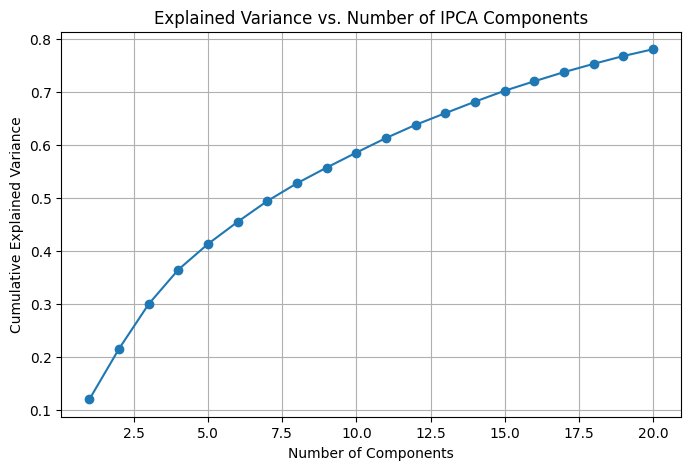

In [41]:
# Get variance info
explained_variance = ipca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Plot
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance vs. Number of IPCA Components")
plt.grid(True)
plt.show()

### Scatter Plot of Digits in 2D (IPCA)

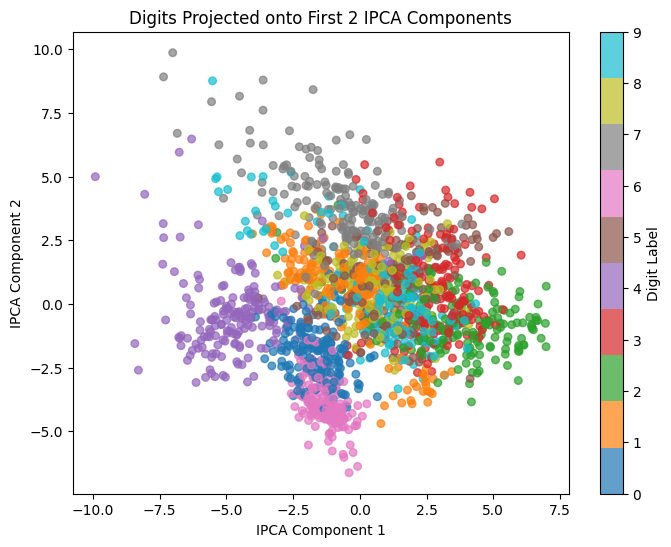

In [42]:
plt.figure(figsize=(8,6))
plt.scatter(X_ipca[:, 0], X_ipca[:, 1], 
            c=y, cmap='tab10', alpha=0.7, s=30)
plt.colorbar(label="Digit Label")
plt.xlabel("IPCA Component 1")
plt.ylabel("IPCA Component 2")
plt.title("Digits Projected onto First 2 IPCA Components")
plt.show()


### Reconstruct images from the reduced components (original vs reconstructed digits)

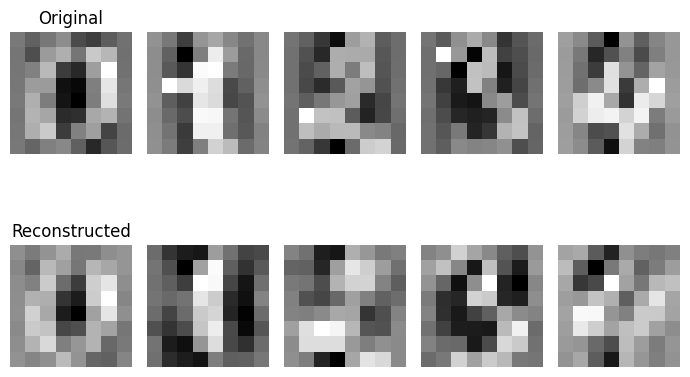

In [43]:
# Reconstruct images
X_reconstructed = ipca.inverse_transform(X_ipca)

# Plot original vs reconstructed for first 5 samples
fig, axes = plt.subplots(2, 5, figsize=(7, 5))

for i in range(5):
    # Original
    axes[0, i].imshow(X_scaled[i].reshape(8, 8), cmap='gray')
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_title("Original")

    # Reconstructed
    axes[1, i].imshow(X_reconstructed[i].reshape(8, 8), cmap='gray')
    axes[1, i].axis("off")
    if i == 0:
        axes[1, i].set_title("Reconstructed")

plt.tight_layout()
plt.show()


### Train a Classifier on IPCA Features

We’ll use Logistic Regression (simple and effective for digit recognition).

Accuracy on test set: 0.9472222222222222


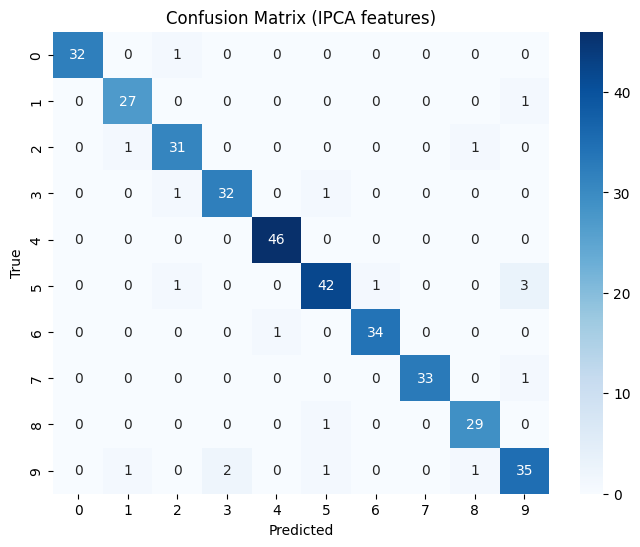

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X_ipca, y, test_size=0.2, random_state=42)

# Train classifier
clf = LogisticRegression(max_iter=2000)
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy on test set:", acc)

# Confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (IPCA features)")
plt.show()